In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy, assemble_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

In [2]:
def Fichera(deg,N):
    kvs = 7*(3 * (bspline.make_knots(deg, 0.0, 1.0, N),),)
    
    #define geometry
    geos = [
        geometry.unit_cube(),
        geometry.unit_cube().translate(( 0,  0, -1)),
        geometry.unit_cube().translate(( 0, -1,  0)),
        geometry.unit_cube().translate((-1,  0,  0)),
        geometry.unit_cube().translate((-1, -1,  0)),
        geometry.unit_cube().translate((-1,  0, -1)),
        geometry.unit_cube().translate(( 0, -1, -1)),
        geometry.unit_cube().translate((-1, -1, -1))
    ]
    
    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch3D(patches)
    return M

In [3]:
def has_origin(M):
    out={}
    for p in range(len(M.patches)):
        if np.any(np.all(np.isclose(topology.corners(M.geos[p]), np.array([0,0,0]), atol=1e-14), axis=-1)):
            out[p]=None
    return out

In [62]:
M = Fichera(1,1)

In [64]:
M.set_boundary_id({1:{(2,2),(6,2),(4,2),(4,4),(3,4),(5,4),(6,0),(1,0),(5,0),(6,4),(5,2),(4,0)}})

In [81]:
M.h_refine(has_origin(M));

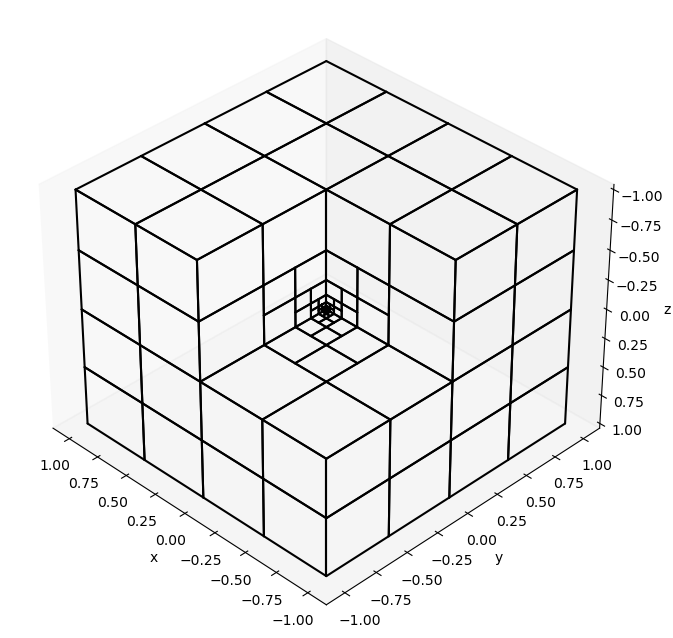

In [82]:
M.plot_boundary()